In [2]:
!pip install kagglehub


In [4]:
import os

# Set your Kaggle API token
os.environ["KAGGLE_API_TOKEN"] = "KGAT_e78dc0c5ac0028ed8b128dd5ee20c26f"

In [6]:
import kagglehub

# This will prompt you to enter your credentials or token securely
kagglehub.login()

Kaggle credentials set.
Kaggle credentials successfully validated.


In [7]:
import kagglehub
import pandas as pd
import os

# Download the dataset
path = kagglehub.dataset_download("jonihoppen/noshowappointments")
print("Path to dataset files:", path)

# Load the CSV file into a pandas dataframe
csv_file_path = os.path.join(path, "KaggleV2-May-2016.csv")
df = pd.read_csv(csv_file_path)

# View the first few rows
df.head()

KaggleApiHTTPError: 403 Client Error.

You don't have permission to access resource at URL: https://api.kaggle.com/v1/datasets.DatasetApiService/GetDataset. Please make sure you are authenticated if you are trying to access a private resource or a resource requiring consent.

In [8]:
import kagglehub

# Download latest version of the dataset
path = kagglehub.dataset_download("joniarroba/noshowappointments")

print("Path to dataset files:", path)

100%|██████████| 2.40M/2.40M [00:00<00:00, 103MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/joniarroba/noshowappointments/versions/5


In [9]:
import os
import pandas as pd

# The path returned from kagglehub
path = "/root/.cache/kagglehub/datasets/joniarroba/noshowappointments/versions/5"

# See what files are inside this directory
print(os.listdir(path))

# Load the CSV file (typically named 'KaggleV2-May-2016.csv')
file_path = os.path.join(path, "KaggleV2-May-2016.csv")
df = pd.read_csv(file_path)

# Display the first 5 rows of the dataset
df.head()

['KaggleV2-May-2016.csv']


,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show
0,2.987250e+13,5642903,F,2016-04-29T18:38:08Z,2016-04-29T00:00:00Z,62,JARDIM DA PENHA,0,1,0,0,0,0,No
1,5.589978e+14,5642503,M,2016-04-29T16:08:27Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,0,0,0,0,0,No
2,4.262962e+12,5642549,F,2016-04-29T16:19:04Z,2016-04-29T00:00:00Z,62,MATA DA PRAIA,0,0,0,0,0,0,No
3,8.679512e+11,5642828,F,2016-04-29T17:29:31Z,2016-04-29T00:00:00Z,8,PONTAL DE CAMBURI,0,0,0,0,0,0,No
4,8.841186e+12,5642494,F,2016-04-29T16:07:23Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,1,1,0,0,0,No


In [10]:
# 1. Check data types, non-null counts, and memory usage
df.info()

# 2. Check for any missing values across columns
print("\nMissing values:")
print(df.isnull().sum())

# 3. Check the first few unique values of the target column (usually 'No-show')
print("\nTarget column preview:")
if 'No-show' in df.columns:
    print(df['No-show'].value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110527 entries, 0 to 110526
Data columns (total 14 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   PatientId       110527 non-null  float64
 1   AppointmentID   110527 non-null  int64  
 2   Gender          110527 non-null  object 
 3   ScheduledDay    110527 non-null  object 
 4   AppointmentDay  110527 non-null  object 
 5   Age             110527 non-null  int64  
 6   Neighbourhood   110527 non-null  object 
 7   Scholarship     110527 non-null  int64  
 8   Hipertension    110527 non-null  int64  
 9   Diabetes        110527 non-null  int64  
 10  Alcoholism      110527 non-null  int64  
 11  Handcap         110527 non-null  int64  
 12  SMS_received    110527 non-null  int64  
 13  No-show         110527 non-null  object 
dtypes: float64(1), int64(8), object(5)
memory usage: 11.8+ MB

Missing values:
PatientId         0
AppointmentID     0
Gender            0
ScheduledDay 

In [11]:
import pandas as pd

# 1. Convert date columns to datetime format
df['ScheduledDay'] = pd.to_datetime(df['ScheduledDay'])
df['AppointmentDay'] = pd.to_datetime(df['AppointmentDay'])

# 2. Extract useful features from dates (e.g., waiting days, day of the week)
# Waiting days = difference between appointment day and scheduled day
df['WaitingDays'] = (df['AppointmentDay'].dt.normalize() - df['ScheduledDay'].dt.normalize()).dt.days

# Day of the week for the appointment (0 = Monday, 6 = Sunday)
df['AppointmentDayOfWeek'] = df['AppointmentDay'].dt.day_name()

# 3. Map the target variable 'No-show' to binary (Yes = 1, No = 0)
if 'No-show' in df.columns:
    df['NoShow_Binary'] = df['No-show'].map({'Yes': 1, 'No': 0})

# Verify the changes
print(df[['ScheduledDay', 'AppointmentDay', 'WaitingDays', 'AppointmentDayOfWeek', 'No-show']].head())

               ScheduledDay            AppointmentDay  WaitingDays  \
0 2016-04-29 18:38:08+00:00 2016-04-29 00:00:00+00:00            0   
1 2016-04-29 16:08:27+00:00 2016-04-29 00:00:00+00:00            0   
2 2016-04-29 16:19:04+00:00 2016-04-29 00:00:00+00:00            0   
3 2016-04-29 17:29:31+00:00 2016-04-29 00:00:00+00:00            0   
4 2016-04-29 16:07:23+00:00 2016-04-29 00:00:00+00:00            0   

  AppointmentDayOfWeek No-show  
0               Friday      No  
1               Friday      No  
2               Friday      No  
3               Friday      No  
4               Friday      No  


In [12]:
# 1. Check for anomalies like negative waiting days or negative ages
print("Negative waiting days count:", (df['WaitingDays'] < 0).sum())
print("Negative ages count:", (df['Age'] < 0).sum())

# 2. View the overall percentage distribution of the target variable
no_show_percentage = df['No-show'].value_counts(normalize=True) * 100
print("\nNo-show Percentage Breakdown:")
print(no_show_percentage)

Negative waiting days count: 5
Negative ages count: 1

No-show Percentage Breakdown:
No-show
No     79.806744
Yes    20.193256
Name: proportion, dtype: float64


In [13]:
# Remove rows with negative waiting days or negative age
df = df[(df['WaitingDays'] >= 0) & (df['Age'] >= 0)]

# Verify the new shape of the dataframe
print("Dataset shape after cleaning:", df.shape)

Dataset shape after cleaning: (110521, 17)


In [14]:
# Group by WaitingDays and calculate the average no-show rate (0 to 1)
waiting_analysis = df.groupby('WaitingDays')['NoShow_Binary'].agg(['count', 'mean']).reset_index()
waiting_analysis.columns = ['WaitingDays', 'TotalAppointments', 'NoShowRate']

# Show the first 10 days
print(waiting_analysis.head(10))

   WaitingDays  TotalAppointments  NoShowRate
0            0              38562    0.046471
1            1               5213    0.213505
2            2               6725    0.238216
3            3               2737    0.235294
4            4               5290    0.232703
5            5               3277    0.266097
6            6               4037    0.247956
7            7               4906    0.266816
8            8               2332    0.287307
9            9               1605    0.274143


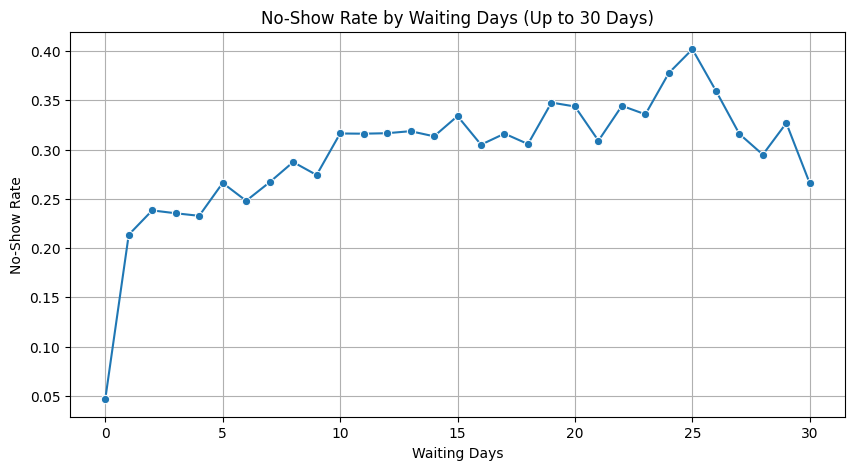

Features dataset ready for modeling. Shape: (110521, 90)


In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Plot No-Show Rate vs Waiting Days (looking at the first 30 days)
plt.figure(figsize=(10, 5))
sns.lineplot(data=waiting_analysis[waiting_analysis['WaitingDays'] <= 30], x='WaitingDays', y='NoShowRate', marker='o')
plt.title('No-Show Rate by Waiting Days (Up to 30 Days)')
plt.xlabel('Waiting Days')
plt.ylabel('No-Show Rate')
plt.grid(True)
plt.show()

# 2. Prepare features for machine learning
# Drop unnecessary or redundant ID and date columns
columns_to_drop = ['PatientId', 'AppointmentID', 'ScheduledDay', 'AppointmentDay', 'No-show', 'AppointmentDayOfWeek']
df_model = df.drop(columns=[col for col in columns_to_drop if col in df.columns])

# One-hot encode categorical features (Gender and Neighbourhood)
df_model = pd.get_dummies(df_model, columns=['Gender', 'Neighbourhood'], drop_first=True)

print("Features dataset ready for modeling. Shape:", df_model.shape)

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

# 1. Separate features (X) and target (y)
X = df_model.drop(columns=['NoShow_Binary'])
y = df_model['NoShow_Binary']

# 2. Split into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")

# 3. Train a Random Forest Classifier (using n_estimators=50 for faster training)
rf_model = RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

# 4. Predict and evaluate
y_pred = rf_model.predict(X_test)
print("\nAccuracy Score:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Training set shape: (88416, 89)
Testing set shape: (22105, 89)

Accuracy Score: 0.7693282062881701

Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.90      0.86     17642
           1       0.39      0.25      0.30      4463

    accuracy                           0.77     22105
   macro avg       0.61      0.58      0.58     22105
weighted avg       0.74      0.77      0.75     22105



In [17]:
# Retrain Random Forest with class_weight='balanced'
rf_balanced = RandomForestClassifier(n_estimators=50, class_weight='balanced', random_state=42, n_jobs=-1)
rf_balanced.fit(X_train, y_train)

# Predict and evaluate the balanced model
y_pred_balanced = rf_balanced.predict(X_test)

print("\nBalanced Model Accuracy Score:", accuracy_score(y_test, y_pred_balanced))
print("\nBalanced Classification Report:\n", classification_report(y_test, y_pred_balanced))


Balanced Model Accuracy Score: 0.7562994797557113

Balanced Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.88      0.85     17642
           1       0.36      0.26      0.30      4463

    accuracy                           0.76     22105
   macro avg       0.59      0.57      0.58     22105
weighted avg       0.73      0.76      0.74     22105



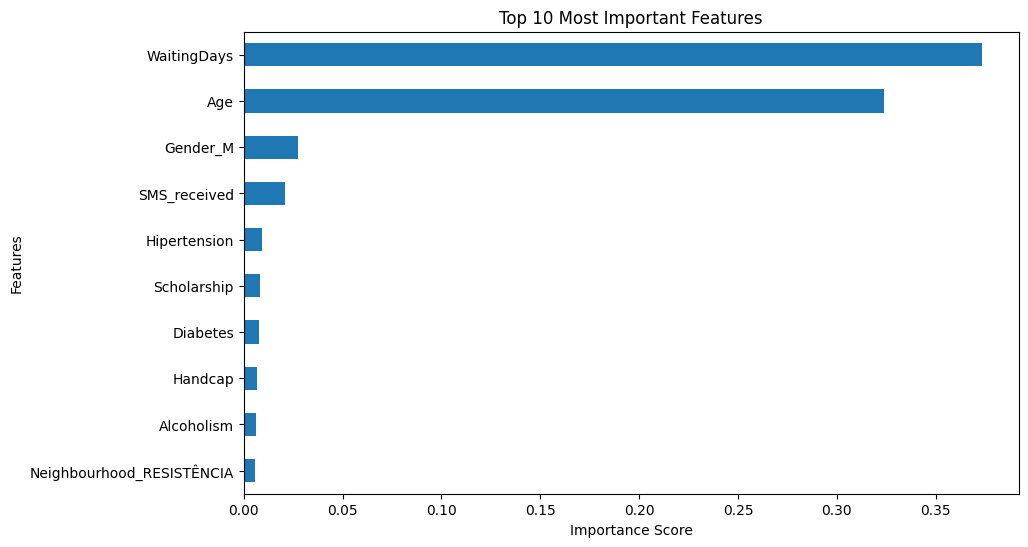

In [18]:
import pandas as pd
import matplotlib.pyplot as plt

# Get feature importances from the balanced model
feature_importances = pd.Series(rf_balanced.feature_importances_, index=X_train.columns)

# Plot the top 10 most important features
plt.figure(figsize=(10, 6))
feature_importances.nlargest(10).plot(kind='barh')
plt.title('Top 10 Most Important Features')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.gca().invert_yaxis()  # Put the highest importance at the top
plt.show()

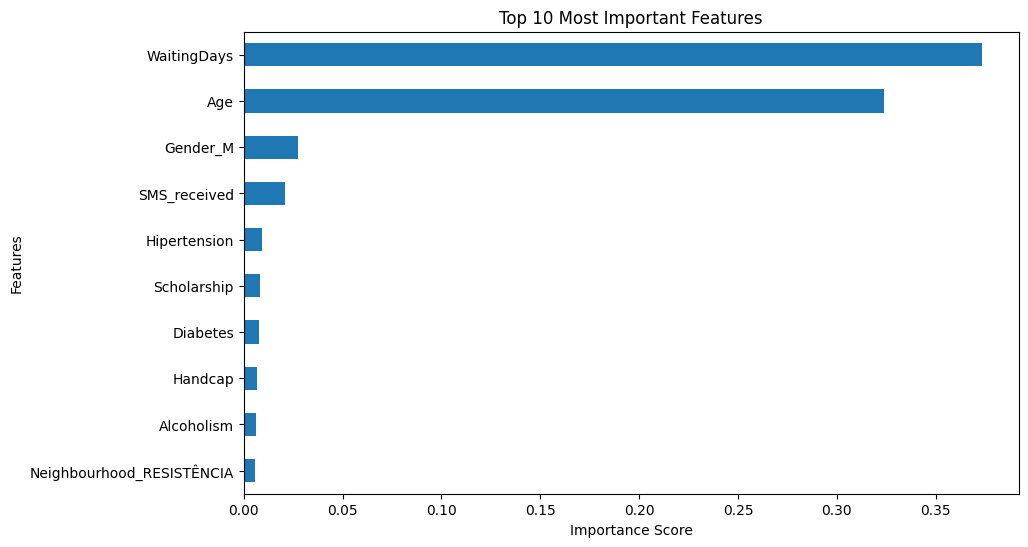

In [19]:
import pandas as pd
import matplotlib.pyplot as plt

# Get feature importances from the balanced model
feature_importances = pd.Series(rf_balanced.feature_importances_, index=X_train.columns)

# Plot the top 10 most important features
plt.figure(figsize=(10, 6))
feature_importances.nlargest(10).plot(kind='barh')
plt.title('Top 10 Most Important Features')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.gca().invert_yaxis()  # Put the highest importance at the top
plt.show()

ROC-AUC Score: 0.6964


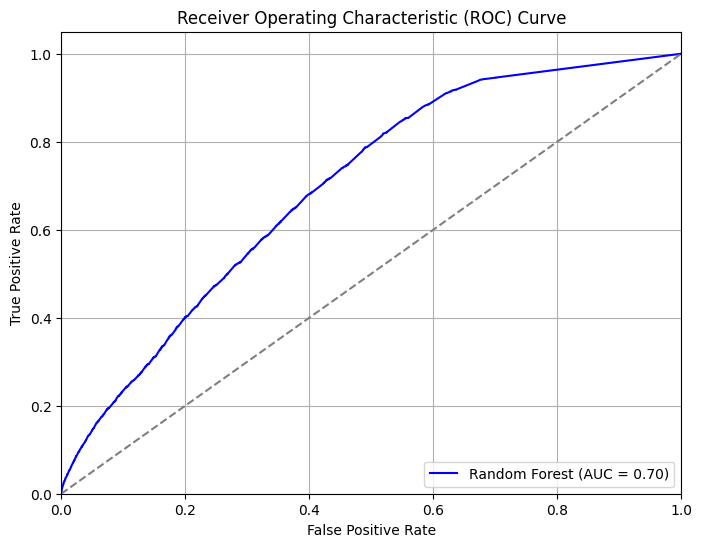

In [20]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# 1. Get predicted probabilities for the positive class (No-show = 1)
y_prob = rf_balanced.predict_proba(X_test)[:, 1]

# 2. Calculate ROC-AUC score
roc_auc = roc_auc_score(y_test, y_prob)
print(f"ROC-AUC Score: {roc_auc:.4f}")

# 3. Compute ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# 4. Plot the ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label=f'Random Forest (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

Confusion Matrix:
[[15562  2080]
 [ 3307  1156]]


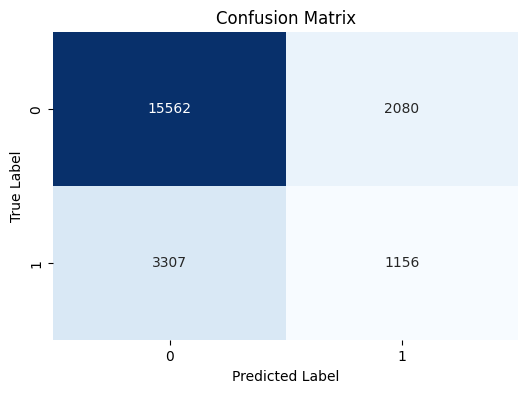


Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.88      0.85     17642
           1       0.36      0.26      0.30      4463

    accuracy                           0.76     22105
   macro avg       0.59      0.57      0.58     22105
weighted avg       0.73      0.76      0.74     22105



In [21]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Generate predictions using your test data (using 0.5 threshold or your tuned threshold)
y_pred = rf_balanced.predict(X_test)

# 2. Compute the Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(conf_matrix)

# 3. Plot the Confusion Matrix as a heatmap for clear visualization
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# 4. Print the Classification Report (Precision, Recall, F1-Score)
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

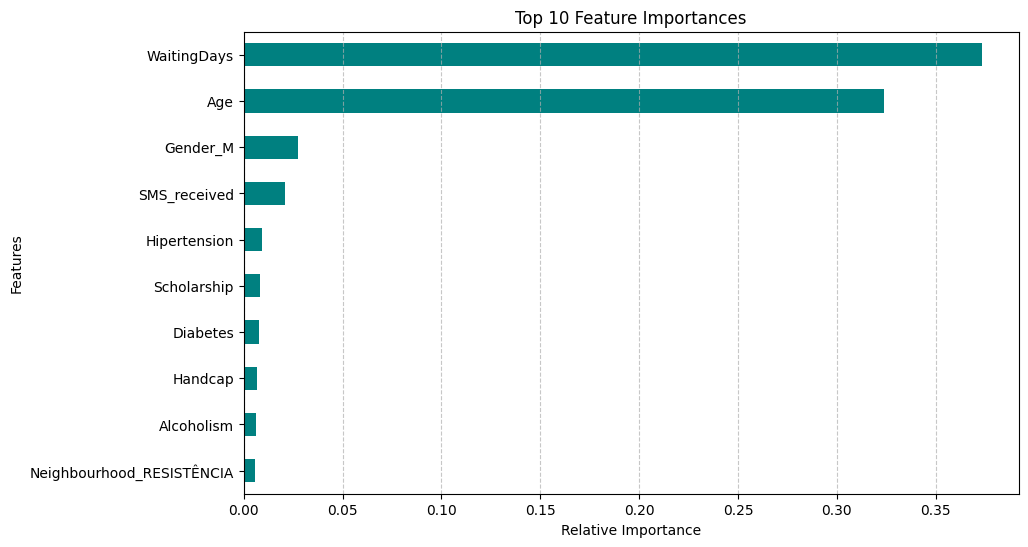

In [22]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Extract feature importances from the random forest model
importance = pd.Series(rf_balanced.feature_importances_, index=X_train.columns)

# 2. Plot the top 10 most important features
plt.figure(figsize=(10, 6))
importance.nlargest(10).plot(kind='barh', color='teal')
plt.title('Top 10 Feature Importances')
plt.xlabel('Relative Importance')
plt.ylabel('Features')
plt.gca().invert_yaxis()  # Put the highest importance at the top
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()